In [2]:
import numpy as np
from matplotlib import pyplot as plt
from functools import partial
from scipy.special import expit as sigmoid, logit

In [3]:
THRESHOLD = 0.25

Net Benefit depends on sharp transition from being classified as 'negative' to 'positive' around the threshold probability.
Seen as a function of threshold probability, net benefit is a step function

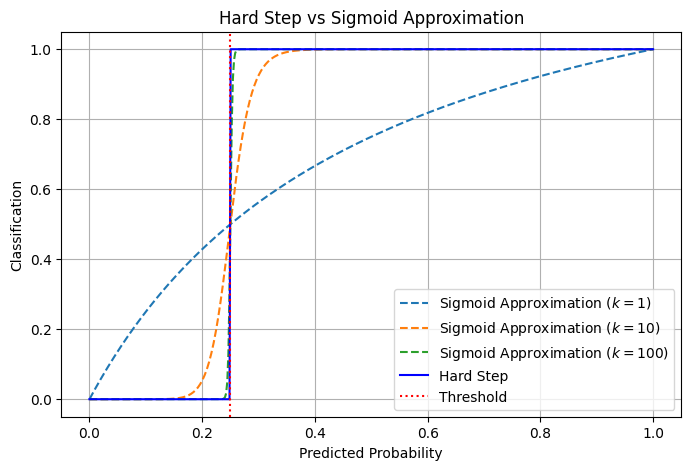

In [4]:
# plot hard step function and sigmoid approximation
def hard_step(x, threshold=0.5):
    return (x >= threshold).astype(float)

def sigmoid_logit(pred, threshold, inv_temp=1.0):
    logits = logit(pred)
    threshold_logit = logit(threshold)

    return sigmoid(inv_temp * (logits - threshold_logit))

inv_temps = [1, 10, 100]

def plot_step_and_sigmoid(ax, threshold=0.5, inv_temps=[50]):
    x = np.linspace(0, 1, 500)
    y_hard = hard_step(x, threshold)
    for inv_temp in inv_temps:
        # y_sigmoid = sigmoid(inv_temp * (x - threshold))
        y_sigmoid = sigmoid_logit(x, threshold, inv_temp)
        ax.plot(x, y_sigmoid, label='Sigmoid Approximation ($k={}$)'.format(inv_temp), linestyle='--')
    ax.plot(x, y_hard, label='Hard Step', color='blue')
    ax.axvline(threshold, color='red', linestyle=':', label='Threshold')
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Classification')
    ax.set_title('Hard Step vs Sigmoid Approximation')
    ax.legend()
    ax.grid()
fig, ax = plt.subplots(figsize=(8, 5))
plot_step_and_sigmoid(ax, threshold=THRESHOLD, inv_temps=inv_temps)
plt.show()

# export figure in png and svg formats
fig.savefig('hard_step_sigmoid_comparison.png', dpi=300)
fig.savefig('hard_step_sigmoid_comparison.svg')

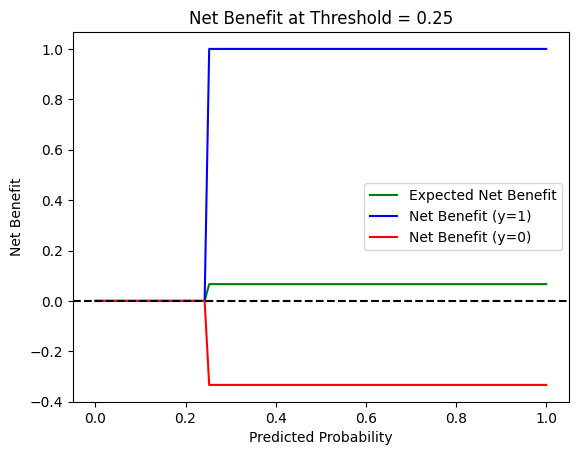

In [5]:
def net_benefit_point(pred, y, treshold):
    """
    Compute the net benefit at a given threshold.
    """
    pos_pred = pred >= treshold
    w_t = treshold / (1 - treshold)
    nb = (y * pos_pred) - (w_t * (1 - y) * pos_pred)
    
    return nb

p_true = 0.3  # True prevalence
preds = np.linspace(0, 1, 100)  # Predicted probabilities
threshold = THRESHOLD

# plot net benefit for different thresholds
nb1 = net_benefit_point(preds, 1, threshold)
nb0 = net_benefit_point(preds, 0, threshold)

# calculate expected net benefit based on true prevalence
# nbe = p_true * nb1 + (1 - p_true) * nb0

def expected_net_benefit(pred, p_true, threshold):
    nb1 = net_benefit_point(pred, 1, threshold)
    nb0 = net_benefit_point(pred, 0, threshold)
    return p_true * nb1 + (1 - p_true) * nb0

nbe_func = partial(expected_net_benefit, p_true=p_true, threshold=threshold)
nbe = nbe_func(preds)

# plot net benefit for y=0, y=1 and expected net benefit in single plot
plt.plot(preds, nbe, label='Expected Net Benefit', color='green')
plt.plot(preds, nb1, label='Net Benefit (y=1)', color='blue')
plt.plot(preds, nb0, label='Net Benefit (y=0)', color='red')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Predicted Probability')
plt.ylabel('Net Benefit')
plt.title('Net Benefit at Threshold = {}'.format(threshold))
plt.legend()
plt.show()

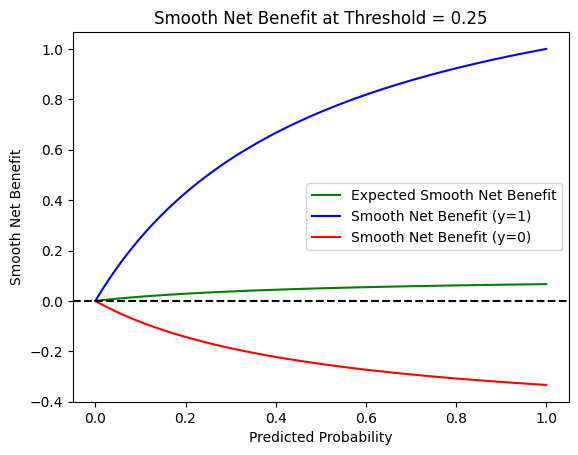

In [6]:
# define smooth approximation of net benefit
def smooth_net_benefit_logit(pred, y, threshold, inv_temp=1.0):
    logit_pred = logit(pred)
    threshold_logit = logit(threshold)
    s = sigmoid(inv_temp * (logit_pred - threshold_logit))
    w_t = threshold / (1 - threshold)
    nb = (y * s) - (w_t * (1 - y) * s)

    return nb

def expected_smooth_net_benefit_logit(pred, p_true, threshold, inv_temp=1.0):
    snb0 = smooth_net_benefit_logit(pred, 0, threshold, inv_temp)
    snb1 = smooth_net_benefit_logit(pred, 1, threshold, inv_temp)
    s_nbe = p_true * snb1 + (1 - p_true) * snb0

    return s_nbe

inv_temp = 1.0

snb0 = smooth_net_benefit_logit(preds, 0, threshold, inv_temp)
snb1 = smooth_net_benefit_logit(preds, 1, threshold, inv_temp)
s_nbe = expected_smooth_net_benefit_logit(preds, p_true, threshold, inv_temp)

# plot smooth net benefit for y=0, y=1 and expected net benefit in single plot
plt.plot(preds, s_nbe, label='Expected Smooth Net Benefit', color='green')
plt.plot(preds, snb1, label='Smooth Net Benefit (y=1)', color='blue')
plt.plot(preds, snb0, label='Smooth Net Benefit (y=0)', color='red')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Predicted Probability')
plt.ylabel('Smooth Net Benefit')
plt.title('Smooth Net Benefit at Threshold = {}'.format(threshold))
plt.legend()
plt.show()


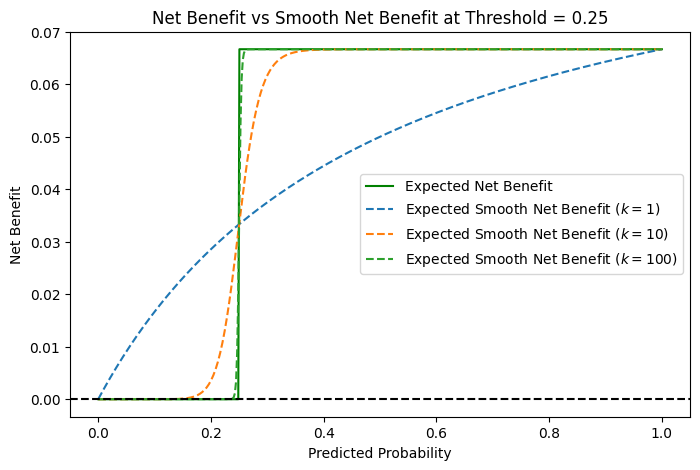

In [7]:
# plot expected net benefit vs expected smooth net benefit for fixed threshold but varying inv_temps
def plot_net_benefit_comparison(ax, threshold=0.5, inv_temps=[1, 10, 100]):
    x = np.linspace(0, 1, 500)
    p_true = 0.3
    nbe = expected_net_benefit(x, p_true, threshold)
    ax.plot(x, nbe, label='Expected Net Benefit', color='green')
    
    for inv_temp in inv_temps:
        s_nbe = expected_smooth_net_benefit_logit(x, p_true, threshold, inv_temp)
        ax.plot(x, s_nbe, label='Expected Smooth Net Benefit ($k={}$)'.format(inv_temp), linestyle='--')
    
    ax.axhline(0, color='black', linestyle='--')
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Net Benefit')
    ax.set_title('Net Benefit vs Smooth Net Benefit at Threshold = {}'.format(threshold))

def average_expected_net_benefit(pred, p_true, thresholds):
    nbe_by_threshold = [expected_net_benefit(pred, p_true, threshold) for threshold in thresholds]
    return np.mean(nbe_by_threshold, axis=0)

def average_expected_smooth_net_benefit_logit(pred, p_true, thresholds, inv_temp=1.0):
    snbe_by_threshold = [
        expected_smooth_net_benefit_logit(pred, p_true, threshold, inv_temp)
        for threshold in thresholds
    ]
    return np.mean(snbe_by_threshold, axis=0)

def plot_average_net_benefit_comparison(
    ax,
    threshold_min=0.2,
    threshold_max=0.3,
    num_thresholds=20,
    inv_temps=[1, 10, 100],
):
    x = np.linspace(0, 1, 500)
    p_true = 0.3
    thresholds = np.linspace(threshold_min, threshold_max, num_thresholds)
    nbe = average_expected_net_benefit(x, p_true, thresholds)
    ax.plot(x, nbe, label='Average Expected Net Benefit', color='green')

    for inv_temp in inv_temps:
        s_nbe = average_expected_smooth_net_benefit_logit(x, p_true, thresholds, inv_temp)
        ax.plot(
            x,
            s_nbe,
            label='Average Expected Smooth Net Benefit ($k={}$)'.format(inv_temp),
            linestyle='--',
        )

    ax.axhline(0, color='black', linestyle='--')
    ax.axvspan(threshold_min, threshold_max, color='gray', alpha=0.08)
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Net Benefit')
    ax.set_title(
        'Average Net Benefit vs Smooth Net Benefit, Thresholds = {:.2f}-{:.2f}'.format(
            threshold_min,
            threshold_max,
        )
    )

fig, ax = plt.subplots(figsize=(8, 5))
plot_net_benefit_comparison(ax, threshold=THRESHOLD, inv_temps=inv_temps)
plt.legend()
plt.show()

# export figure in png and svg formats
fig.savefig('net_benefit_comparison.png', dpi=300)
fig.savefig('net_benefit_comparison.svg')

fig, ax = plt.subplots(figsize=(8, 5))
plot_average_net_benefit_comparison(
    ax,
    threshold_min=0.2,
    threshold_max=0.3,
    num_thresholds=20,
    inv_temps=inv_temps,
)
plt.legend()
fig.tight_layout()
plt.show()

# export average-threshold variant in png and svg formats
fig.savefig('average_net_benefit_comparison_threshold_0.20_0.30.png', dpi=300)
fig.savefig('average_net_benefit_comparison_threshold_0.20_0.30.svg')

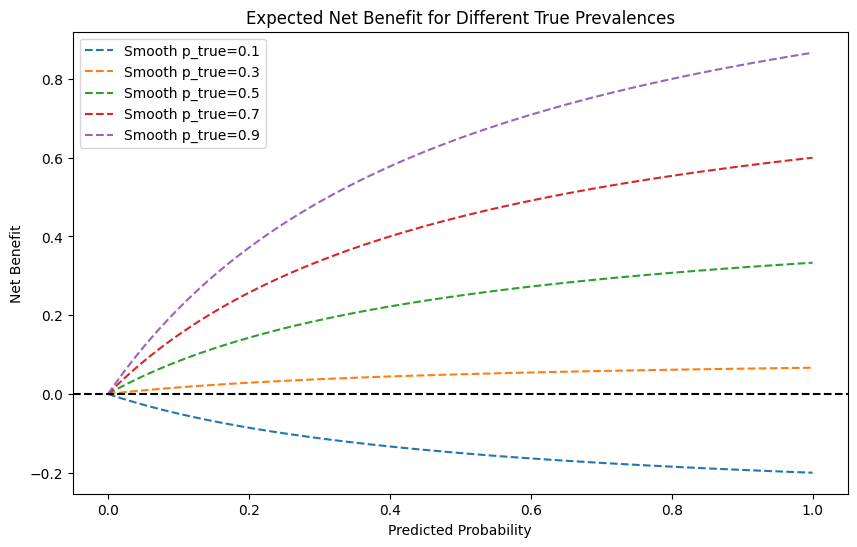

In [8]:
# plot expected net benefit and smooth nb for different values of p_true
p_trues = [0.1, 0.3, 0.5, 0.7, 0.9]
plt.figure(figsize=(10, 6))
for p_true in p_trues:
    nbe = p_true * nb1 + (1 - p_true) * nb0
    snbe = expected_smooth_net_benefit_logit(preds, p_true, threshold, inv_temp)
    # plt.plot(preds, nbe, label='p_true={}'.format(p_true))
    plt.plot(preds, snbe, label='Smooth p_true={}'.format(p_true), linestyle='--')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Predicted Probability')
plt.ylabel('Net Benefit')
plt.title('Expected Net Benefit for Different True Prevalences')
plt.legend()
plt.show()